# 05 — Explicabilidad del Modelo
## LoanRisk-ML

Usamos SHAP para entender qué variables impulsan las predicciones
del modelo XGBoost ganador a nivel global e individual.

### Objetivos
- Crear el SHAP TreeExplainer sobre el modelo XGBoost
- Generar beeswarm plot de importancia global de features
- Analizar préstamos individuales con waterfall plot
- Análisis de fairness por segmento (loan_purpose, addr_state)
- Guardar el explainer para uso en producción

### ¿Por qué SHAP?
SHAP (SHapley Additive exPlanations) asigna a cada feature su contribución
exacta a la predicción — interpretable tanto a nivel global como individual.
A diferencia de la importancia de features nativa de XGBoost, SHAP es
consistente y localmente preciso.

### Input
`data/processed/X_test.parquet`, `y_test.parquet`
`models/XGBoost_best.joblib`

### Output
`models/shap_explainer.joblib`

## 1. Importaciones

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import shap
from pathlib import Path

print("Librerías cargadas correctamente")

Librerías cargadas correctamente


## 2. Carga del modelo y datos

In [2]:
ROOT           = Path('..').resolve()
DATA_PROCESSED = ROOT / 'data' / 'processed'
MODELS_DIR     = ROOT / 'models'

# Cargar modelo ganador
model = joblib.load(MODELS_DIR / 'XGBoost_best.joblib')

# Cargar datos de test
X_test = pd.read_parquet(DATA_PROCESSED / 'X_test.parquet')
y_test = pd.read_parquet(DATA_PROCESSED / 'y_test.parquet').squeeze()

print(f"Modelo cargado: XGBoost")
print(f"X_test: {X_test.shape}")
print(f"Default rate test: {y_test.mean():.2%}")

Modelo cargado: XGBoost
X_test: (58675, 76)
Default rate test: 20.15%


## 3. Crear SHAP TreeExplainer

TreeExplainer está optimizado para modelos basados en árboles
como XGBoost, LightGBM y CatBoost — calcula SHAP values exactos
de forma eficiente sin aproximaciones.

In [3]:
explainer = shap.TreeExplainer(model)

print("SHAP TreeExplainer creado correctamente")
print(f"Tipo de modelo: {type(model).__name__}")

SHAP TreeExplainer creado correctamente
Tipo de modelo: XGBClassifier


## 4. Calcular SHAP values

Calculamos SHAP values sobre una muestra de X_test.
Usamos 2000 filas para que sea rápido sin perder representatividad.

In [4]:
# Muestra representativa de test
X_sample = X_test.sample(n=2000, random_state=42)
y_sample  = y_test.iloc[X_sample.index]

# Calcular SHAP values
shap_values = explainer(X_sample)

print(f"SHAP values calculados sobre {len(X_sample)} préstamos")
print(f"Shape de shap_values: {shap_values.values.shape}")
print(f"  Filas: {shap_values.values.shape[0]} préstamos")
print(f"  Columnas: {shap_values.values.shape[1]} features")

SHAP values calculados sobre 2000 préstamos
Shape de shap_values: (2000, 76)
  Filas: 2000 préstamos
  Columnas: 76 features


## 5. Recuperar nombres de features y calcular SHAP values

In [5]:
# Cargar preprocesador para recuperar nombres de columnas
preprocessor = joblib.load(MODELS_DIR / 'preprocessor.joblib')

# Recuperar nombres en el mismo orden que el ColumnTransformer
num_cols      = preprocessor.transformers_[0][2]
cat_cols      = preprocessor.transformers_[1][2]
feature_names = num_cols + cat_cols

print(f"Total features: {len(feature_names)}")
print(f"Numéricas:      {len(num_cols)}")
print(f"Categóricas:    {len(cat_cols)}")

# Asignar nombres correctos a X_sample
X_sample = X_test.sample(n=2000, random_state=42).copy()
X_sample.columns = feature_names

# Calcular SHAP values con nombres correctos
shap_values = explainer(X_sample)

print(f"\nSHAP values calculados sobre {len(X_sample)} préstamos")
print(f"Shape: {shap_values.values.shape}")

Total features: 76
Numéricas:      72
Categóricas:    4

SHAP values calculados sobre 2000 préstamos
Shape: (2000, 76)


## 6. Beeswarm plot — Importancia global de features

El beeswarm muestra la distribución de los SHAP values para cada feature.
Cada punto es un préstamo — color rojo indica valor alto de la feature,
azul indica valor bajo. La posición horizontal indica el impacto en la predicción.

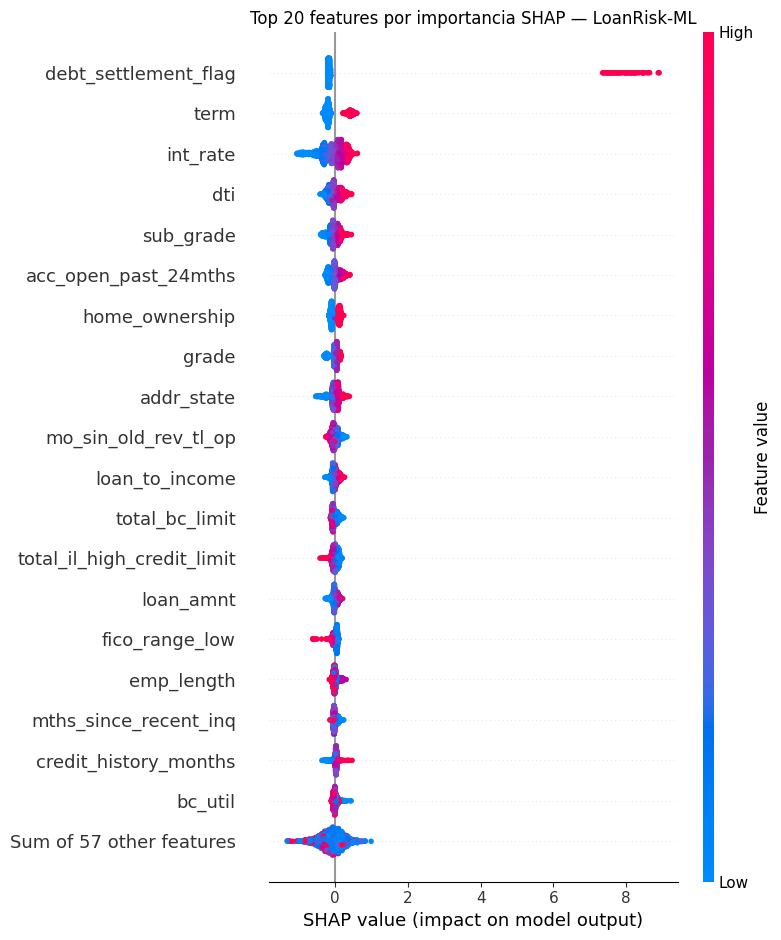

Beeswarm plot guardado en reports/shap_beeswarm.png


In [6]:
plt.figure()
shap.plots.beeswarm(shap_values, max_display=20, show=False)
plt.title('Top 20 features por importancia SHAP — LoanRisk-ML')
plt.tight_layout()
plt.savefig(ROOT / 'reports' / 'shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()
print("Beeswarm plot guardado en reports/shap_beeswarm.png")

## 7. Waterfall plot — Explicación de un préstamo individual

El waterfall muestra cómo cada feature empuja la predicción
hacia arriba (más riesgo) o hacia abajo (menos riesgo)
para un préstamo específico.

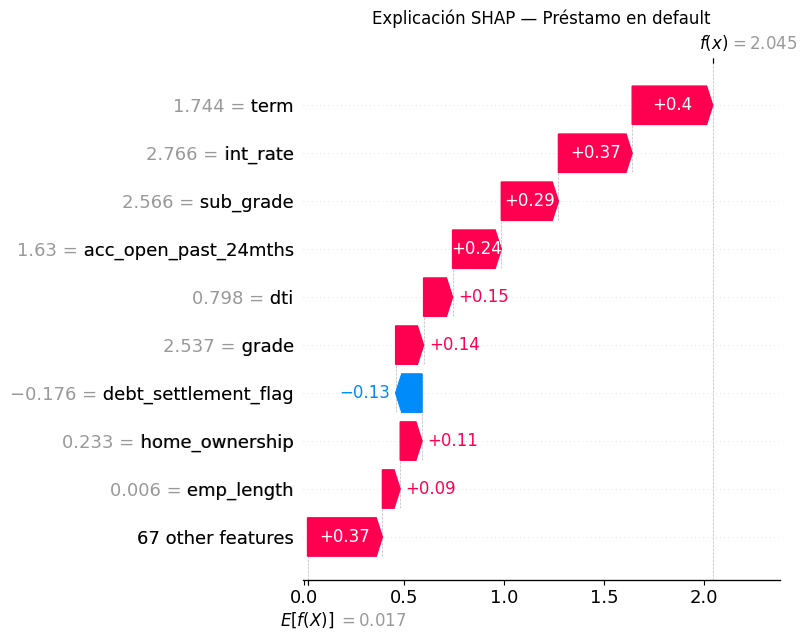

Waterfall guardado en reports/shap_waterfall_default.png


In [7]:
# Elegir un préstamo que defaulteó
y_sample = y_test.loc[X_sample.index]
idx_defaults = y_sample[y_sample == 1].index
primera_default = X_sample.index.get_loc(idx_defaults[0])

plt.figure()
shap.plots.waterfall(shap_values[primera_default], show=False)
plt.title('Explicación SHAP — Préstamo en default')
plt.tight_layout()
plt.savefig(ROOT / 'reports' / 'shap_waterfall_default.png', dpi=150, bbox_inches='tight')
plt.show()
print("Waterfall guardado en reports/shap_waterfall_default.png")

## 8. Análisis de fairness por segmento

Analizamos si el modelo trata de forma equitativa a diferentes
grupos de préstamos — por propósito y por estado.
Esto es especialmente importante en credit scoring donde
decisiones sesgadas pueden tener implicaciones regulatorias.

In [8]:
# Cargar loan_features para tener las columnas originales
df_original = pd.read_parquet(DATA_PROCESSED / 'loan_features.parquet')
df_test_original = df_original.loc[X_test.index].copy()

# Predicciones del modelo en test
proba_test = model.predict_proba(X_test)[:, 1]
df_test_original['proba_default'] = proba_test
df_test_original['target'] = y_test.values

# Default rate real vs predicho por propósito del préstamo
fairness_purpose = df_test_original.groupby('purpose').agg(
    default_rate_real=('target', 'mean'),
    default_rate_predicho=('proba_default', 'mean'),
    cantidad=('target', 'count')
).round(4).sort_values('default_rate_real', ascending=False)

print("Default rate real vs predicho por propósito del préstamo:")
print(fairness_purpose.to_string())

Default rate real vs predicho por propósito del préstamo:
                    default_rate_real  default_rate_predicho  cantidad
purpose                                                               
renewable_energy               0.2581                 0.4323        31
moving                         0.2263                 0.4050       358
vacation                       0.2235                 0.4291       349
house                          0.2180                 0.4251       211
medical                        0.2071                 0.3960       705
small_business                 0.2026                 0.4380       543
debt_consolidation             0.2024                 0.4119     33026
other                          0.2016                 0.4088      3398
credit_card                    0.2006                 0.4136     14596
home_improvement               0.1985                 0.4148      3698
major_purchase                 0.1853                 0.4153      1236
car                

## 8.1 Visualización del análisis de fairness

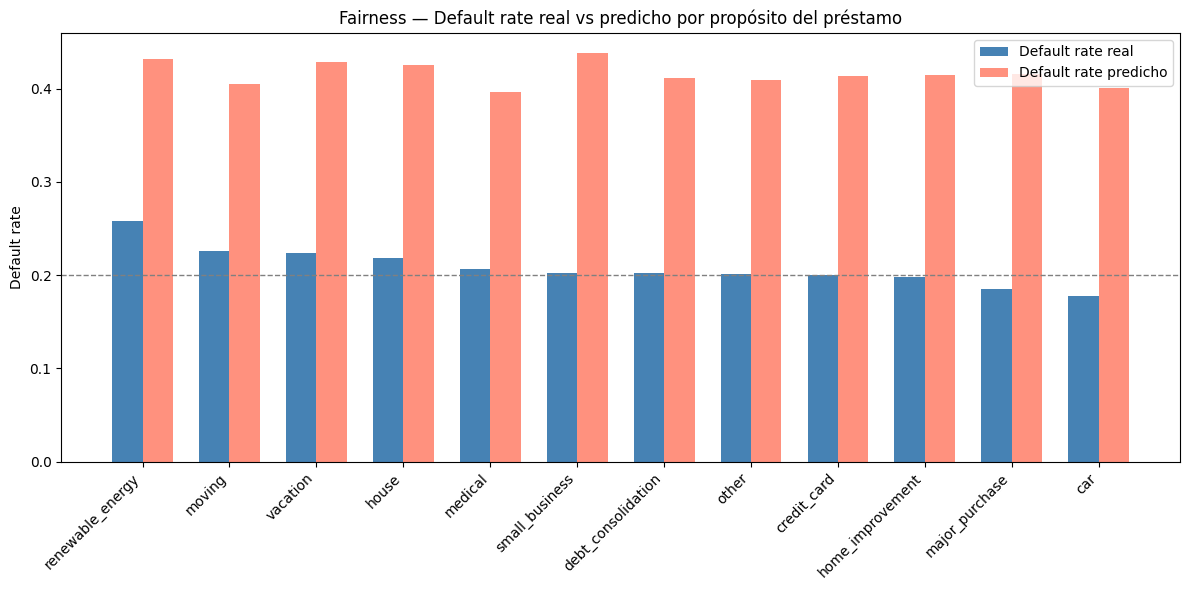

Gráfico guardado en reports/fairness_purpose.png


In [9]:
fig, ax = plt.subplots(figsize=(12, 6))

x = range(len(fairness_purpose))
width = 0.35

bars1 = ax.bar([i - width/2 for i in x], 
               fairness_purpose['default_rate_real'],
               width, label='Default rate real', color='steelblue')

bars2 = ax.bar([i + width/2 for i in x],
               fairness_purpose['default_rate_predicho'],
               width, label='Default rate predicho', color='tomato', alpha=0.7)

ax.set_xticks(x)
ax.set_xticklabels(fairness_purpose.index, rotation=45, ha='right')
ax.set_ylabel('Default rate')
ax.set_title('Fairness — Default rate real vs predicho por propósito del préstamo')
ax.legend()
ax.axhline(y=0.20, color='gray', linestyle='--', linewidth=1, label='Default rate global')

plt.tight_layout()
plt.savefig(ROOT / 'reports' / 'fairness_purpose.png', dpi=150, bbox_inches='tight')
plt.show()

print("Gráfico guardado en reports/fairness_purpose.png")

## 9. Guardar SHAP explainer para producción

In [10]:
joblib.dump(explainer, MODELS_DIR / 'shap_explainer.joblib')

print("SHAP explainer guardado en models/shap_explainer.joblib")
print()
print("Archivos generados en este notebook:")
print(f"  models/shap_explainer.joblib")
print(f"  reports/shap_beeswarm.png")
print(f"  reports/shap_waterfall_default.png")
print(f"  reports/fairness_purpose.png")

SHAP explainer guardado en models/shap_explainer.joblib

Archivos generados en este notebook:
  models/shap_explainer.joblib
  reports/shap_beeswarm.png
  reports/shap_waterfall_default.png
  reports/fairness_purpose.png
